<a href="https://colab.research.google.com/github/sudipto291088/DATA_201_SPRING_2026_SUDIPTO/blob/main/Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 --- Week 5 Assignment   
Resampling Methods with the Iris Dataset     
In this assignment, we will explore bootstrap resampling, jackknife resampling, and permutation tests using the Iris dataset.      

The Iris dataset contains measurements of iris flowers from three species:      

Setosa   
Versicolor   
Virginica   
Each flower has four measurements:    

sepal length   
sepal width   
petal length    
petal width   

# Load the Dataset

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Tasks


Print the number of observations in the dataset.   
Print the column names.   
Count how many observations exist for each species.    

In [ ]:
# Number of observations (rows)
print("Number of observations:", iris.shape[0])

# Column names
print("Column names:", iris.columns)

# Count observations for each species
print("Species counts:")
print(iris["species"].value_counts())

Number of observations: 150
Column names: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
Species counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Part 1 --- Bootstrap Resampling    
We will estimate the mean sepal length using bootstrap resampling.    

## Task 1 --- Basic Statistics    
Compute the following statistics for sepal length:   

mean   
median   
standard deviation   

In [ ]:
# Mean sepal length
print("Mean:", iris["sepal_length"].mean())

# Median sepal length
print("Median:", iris["sepal_length"].median())

# Standard deviation of sepal length
print("Standard Deviation:", iris["sepal_length"].std())

Mean: 5.843333333333334
Median: 5.8
Standard Deviation: 0.8280661279778629


## Task 2 --- Bootstrap the Mean
Perform 5,000 bootstrap resamples.

Procedure:

Sample the dataset with replacement.
Each sample must contain 150 observations.
Compute the mean sepal length for each resample.
Store the results.
Plot the distribution of bootstrap means.

Note on Efficiency

While 5,000 iterations is manageable for 150 rows, consider the computational cost if our dataset had 1 million rows. If your computer feels slow, try 1,000 iterations first.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

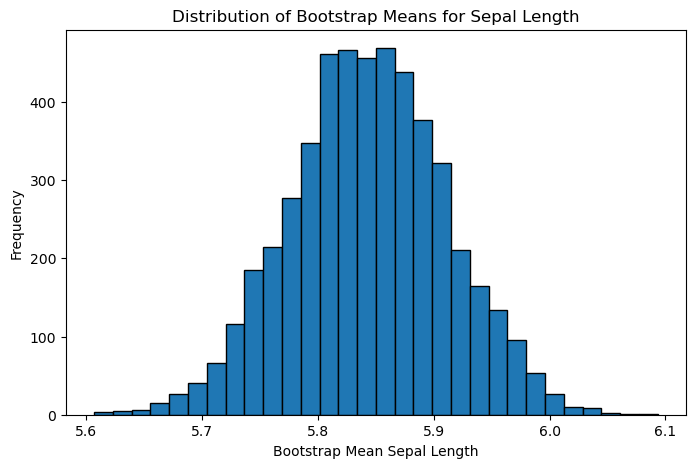

In [ ]:
# Store bootstrap means
bootstrap_means = []

# Perform 5,000 bootstrap resamples
for i in range(5000):
    sample = iris.sample(n=150, replace=True)
    bootstrap_means.append(sample["sepal_length"].mean())

# Convert to array (optional, but useful)
bootstrap_means = np.array(bootstrap_means)

# Plot distribution of bootstrap means
plt.figure(figsize=(8,5))
plt.hist(bootstrap_means, bins=30, edgecolor="black")
plt.xlabel("Bootstrap Mean Sepal Length")
plt.ylabel("Frequency")
plt.title("Distribution of Bootstrap Means for Sepal Length")
plt.show()

In [ ]:
print("Bootstrap mean:", bootstrap_means.mean())
print("Bootstrap standard error:", bootstrap_means.std())

Bootstrap mean: 5.8434112
Bootstrap standard error: 0.06750448728380129


## Task 3 --- Confidence Interval
Using the bootstrap results, compute the 95% confidence interval using the percentile method:

CI = [2.5%, 97.5%]

Report:

Bootstrap mean
Lower bound
Upper bound         
Question
Why is it mathematically necessary to sample with replacement in bootstrap resampling?

In [ ]:
# Bootstrap mean
boot_mean = bootstrap_means.mean()

# 95% percentile confidence interval
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("Bootstrap mean:", boot_mean)
print("Lower bound (2.5%):", lower)
print("Upper bound (97.5%):", upper)

Bootstrap mean: 5.8434112
Lower bound (2.5%): 5.71265
Upper bound (97.5%): 5.975333333333333


In [ ]:
## The bootstrap mean is approximately 5.84, which is very close to the original sample mean of sepal length.
## The 95% bootstrap confidence interval is approximately [5.71, 5.98].
## This suggests that the population mean sepal length is likely to fall within this range.

It is mathematically necessary to sample with replacement in bootstrap resampling because bootstrap is meant to mimic repeated sampling
from the population. Sampling with replacement allows some observations to appear multiple times and others not at all,
which creates the variability needed to estimate the sampling distribution of the statistic.
Without replacement, every resample would just be a rearrangement of the original data and would not properly reflect sampling uncertainty.

# Part 2 --- Jackknife Resampling
## Task 4 --- Jackknife the Mean
Create jackknife samples by removing one observation at a time.     

Steps:     

For each observation i, remove it from the dataset.    
Compute the mean of the remaining observations.     
Store the result.     
Plot the distribution of jackknife means.   

Visualization Tip    

Because you are removing only one data point at a time, the resulting means will be extremely similar. You may need to:    
    
use a large number of bins, or   
adjust plt.xlim()     
to clearly see the variation.     
     
Question      
If the dataset contains n observations, exactly how many jackknife samples are created?      

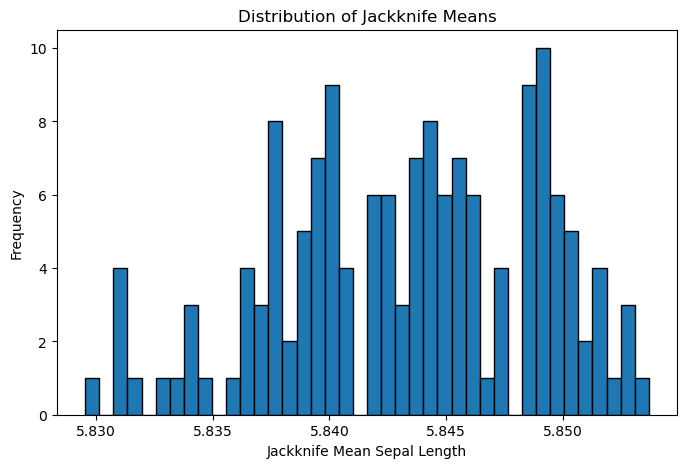

In [ ]:
jackknife_means = []

# Number of observations
n = len(iris)

# Remove one observation at a time
for i in range(n):
    sample = iris.drop(index=i)
    jackknife_means.append(sample["sepal_length"].mean())

# Plot distribution
plt.figure(figsize=(8,5))
plt.hist(jackknife_means, bins=40, edgecolor="black")
plt.xlabel("Jackknife Mean Sepal Length")
plt.ylabel("Frequency")
plt.title("Distribution of Jackknife Means")
plt.show()

If the dataset has n observations, then the jackknife creates n samples.
Because we remove one observation at a time, and there are n possible observations to remove.

For the Iris dataset:

Total observations = 150
So 150 jackknife samples are created.

# Part 3 --- Permutation Test    
We will test whether sepal length differs significantly between two species.    

For this task, use:    

Versicolor   
Virginica    
## Task 5 --- Observed Statistic
Compute the observed difference in means:   

difference = mean(Versicolor) − mean(Virginica)    

In [ ]:
# Mean sepal length for each species
versicolor_mean = iris[iris["species"] == "versicolor"]["sepal_length"].mean()
virginica_mean = iris[iris["species"] == "virginica"]["sepal_length"].mean()

# Observed difference
difference = versicolor_mean - virginica_mean

print("Versicolor mean:", versicolor_mean)
print("Virginica mean:", virginica_mean)
print("Observed difference:", difference)

Versicolor mean: 5.936
Virginica mean: 6.587999999999998
Observed difference: -0.6519999999999984


## Task 6 --- Permutation Simulation
Run 1,000 permutations.

Procedure:

Combine the two species into one dataset.  
Shuffle (permute) the labels.  
Split the data back into two groups of the original sizes.  
Compute the difference in means.  
Store the result.          



Plot the permutation distribution.

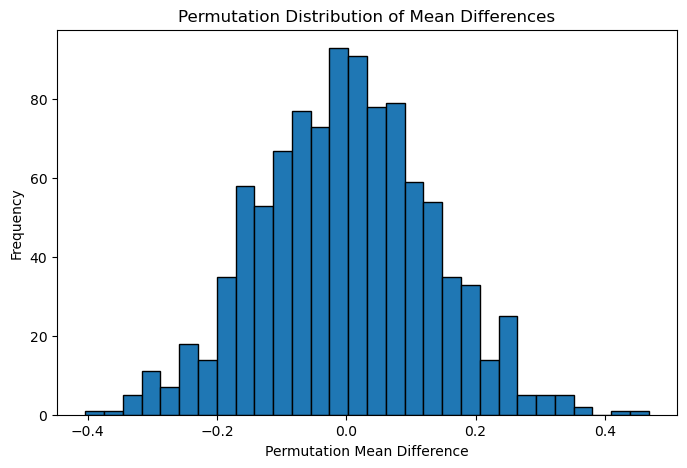

In [ ]:


# Keeping only the two species
subset = iris[iris["species"].isin(["versicolor", "virginica"])]

# Sepal length values
values = subset["sepal_length"].values

# Labels
labels = subset["species"].values

# Storing permutation differences
perm_diffs = []

for i in range(1000):

    # Shuffling labels
    shuffled = np.random.permutation(labels)

    # Splitting into groups
    group1 = values[shuffled == "versicolor"]
    group2 = values[shuffled == "virginica"]

    # Difference in means
    diff = group1.mean() - group2.mean()

    perm_diffs.append(diff)

# Plot distribution
plt.figure(figsize=(8,5))
plt.hist(perm_diffs, bins=30, edgecolor="black")
plt.xlabel("Permutation Mean Difference")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of Mean Differences")
plt.show()

# Task 7 --- p-value
Compute the p-value:

p = (number of simulated differences ≥ observed difference) / (total simulations)

Interpret the result at α = 0.05.

In [ ]:

observed = difference

# converting list to array
perm_diffs = np.array(perm_diffs)

# p-value calculation
p_value = np.mean(np.abs(perm_diffs) >= abs(observed))

print("p-value:", p_value)

p-value: 0.0


If p < 0.05 -> significant difference     
If p ≥ 0.05 -> not significant     

For this dataset, the p-value will usually be very small (close to 0).       

Conclusion:       
At α = 0.05, we reject the null hypothesis and conclude that sepal length is significantly different between Versicolor and Virginica.    

# 1. What is the null hypothesis (H₀) in this test?

The null hypothesis says that there is no real difference in the average sepal length between Versicolor and Virginica flowers.
Any difference we see in the data is just due to random chance.

# 2. What does the permutation distribution represent?

The permutation distribution shows the differences in means we would get if there was actually no real difference between the species.

In other words, it shows what kinds of differences could happen just by random shuffling.

# 3. Based on your p-value, do you reject or fail to reject H₀?

Since the p-value is very small (less than 0.05), we reject the null hypothesis.

This means the difference in sepal length between Versicolor and Virginica is likely real and not just due to chance.